In [3]:
# Import required libraries
import pandas as pd

# Load the cleaned dataset (use the exact file name from Colab)
df = pd.read_csv("Employee_Attrition_Cleaned.csv")

# Check number of rows and columns
print(df.shape)

# Show first 5 rows
df.head()

(1470, 31)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [4]:
# Check data types and non-null counts for every column
df.info()

# Count missing values in each column
print("Missing values per column:")
print(df.isnull().sum())

# Count duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check attrition count (should match our SQL result)
print(df["Attrition"].value_counts())

# Attrition percentage
print(df["Attrition"].value_counts(normalize=True) * 100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [5]:
# Create age groups (same ranges as our SQL query)
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 24, 34, 44, 54, 100],
    labels=["Under 25", "25-34", "35-44", "45-54", "55+"]
)

# Create tenure groups (same ranges as our SQL query)
df["TenureGroup"] = pd.cut(
    df["YearsAtCompany"],
    bins=[-1, 1, 5, 10, 100],
    labels=["0-1 years", "2-5 years", "6-10 years", "10+ years"]
)

# Attrition summary for age groups
age_summary = df.groupby("AgeGroup", observed=True)["Attrition"].agg(
    total="count",
    left=lambda s: (s == "Yes").sum(),
    attrition_pct=lambda s: round((s == "Yes").mean() * 100, 2)
)
print(age_summary)

# Attrition summary for tenure groups
tenure_summary = df.groupby("TenureGroup", observed=True)["Attrition"].agg(
    total="count",
    left=lambda s: (s == "Yes").sum(),
    attrition_pct=lambda s: round((s == "Yes").mean() * 100, 2)
)
print(tenure_summary)

          total  left  attrition_pct
AgeGroup                            
Under 25     97    38          39.18
25-34       554   112          20.22
35-44       505    51          10.10
45-54       245    25          10.20
55+          69    11          15.94
             total  left  attrition_pct
TenureGroup                            
0-1 years      215    75          34.88
2-5 years      561    87          15.51
6-10 years     448    55          12.28
10+ years      246    20           8.13


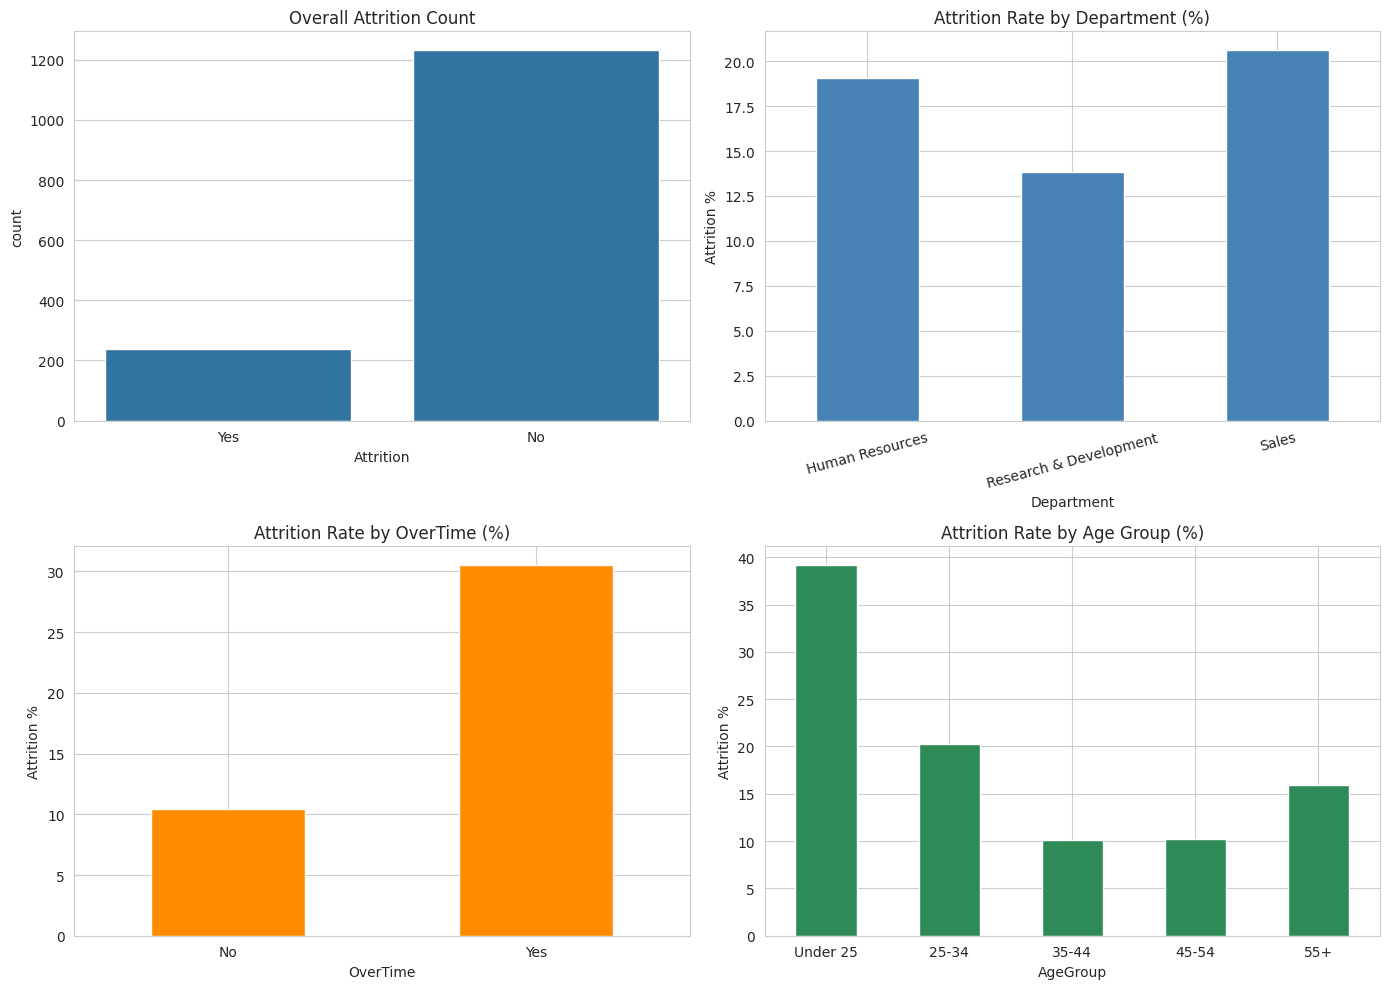

In [6]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean chart style
sns.set_style("whitegrid")

# Helper function: attrition rate (%) by any column
def attrition_rate(column):
    return df.groupby(column, observed=True)["Attrition"].apply(
        lambda s: (s == "Yes").mean() * 100
    )

# Create a 2x2 grid of charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Overall attrition count
sns.countplot(x="Attrition", data=df, ax=axes[0, 0])
axes[0, 0].set_title("Overall Attrition Count")

# Chart 2: Attrition rate by department
attrition_rate("Department").plot(kind="bar", ax=axes[0, 1], color="steelblue")
axes[0, 1].set_title("Attrition Rate by Department (%)")
axes[0, 1].set_ylabel("Attrition %")
axes[0, 1].tick_params(axis="x", rotation=15)

# Chart 3: Attrition rate by overtime
attrition_rate("OverTime").plot(kind="bar", ax=axes[1, 0], color="darkorange")
axes[1, 0].set_title("Attrition Rate by OverTime (%)")
axes[1, 0].set_ylabel("Attrition %")
axes[1, 0].tick_params(axis="x", rotation=0)

# Chart 4: Attrition rate by age group
attrition_rate("AgeGroup").plot(kind="bar", ax=axes[1, 1], color="seagreen")
axes[1, 1].set_title("Attrition Rate by Age Group (%)")
axes[1, 1].set_ylabel("Attrition %")
axes[1, 1].tick_params(axis="x", rotation=0)

# Adjust spacing and show the charts
plt.tight_layout()
plt.show()

In [7]:
# Copy the data so the original stays unchanged
df_corr = df.copy()

# Convert Yes/No to 1/0 so we can find correlation
df_corr["Attrition"] = df_corr["Attrition"].map({"Yes": 1, "No": 0})
df_corr["OverTime"] = df_corr["OverTime"].map({"Yes": 1, "No": 0})

# Keep only numeric columns
numeric_df = df_corr.select_dtypes(include="number")

# Correlation of each column with Attrition
corr_with_attrition = numeric_df.corr()["Attrition"].drop("Attrition").sort_values()
print(corr_with_attrition.round(3))

TotalWorkingYears          -0.171
JobLevel                   -0.169
YearsInCurrentRole         -0.161
MonthlyIncome              -0.160
Age                        -0.159
YearsWithCurrManager       -0.156
StockOptionLevel           -0.137
YearsAtCompany             -0.134
JobInvolvement             -0.130
JobSatisfaction            -0.103
EnvironmentSatisfaction    -0.103
WorkLifeBalance            -0.064
TrainingTimesLastYear      -0.059
DailyRate                  -0.057
RelationshipSatisfaction   -0.046
YearsSinceLastPromotion    -0.033
Education                  -0.031
PercentSalaryHike          -0.013
HourlyRate                 -0.007
PerformanceRating           0.003
MonthlyRate                 0.015
NumCompaniesWorked          0.043
DistanceFromHome            0.078
OverTime                    0.246
Name: Attrition, dtype: float64
